In [134]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.feature_selection import RFE

In [136]:
df = pd.read_csv("emotional_monitoring_dataset_with_target.csv")

df = df.drop_duplicates()

df = df.dropna()

df['EngagementLevel'] = df['EngagementLevel'].replace({1: 1, 2: 1, 3: 2})

# Check if there are any NaN values in the target column (EngagementLevel)
print(df['EngagementLevel'].isnull().sum())

df = df.drop(columns=['EmotionalState', 'CognitiveState'])


0


In [137]:
# Check if there are any NaN values in the target column (EngagementLevel)
print(df.isnull().sum())

# Check for and remove any NaNs in EngagementLevel
df = df.dropna(subset=['EngagementLevel'])

# Features: all columns except EngagementLevel
X = df.drop(columns=['EngagementLevel'])

# Target: EngagementLevel
y = df['EngagementLevel']



# Check for missing values in the feature set
X.fillna(X.mean(), inplace=True)  # Fill NaN values in features

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

HeartRate            0
SkinConductance      0
EEG                  0
Temperature          0
PupilDiameter        0
SmileIntensity       0
FrownIntensity       0
CortisolLevel        0
ActivityLevel        0
AmbientNoiseLevel    0
LightingLevel        0
EngagementLevel      0
dtype: int64
Accuracy: 1.0
Confusion Matrix:
 [[ 84   0]
 [  0 116]]
Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00       116

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [138]:
# Split dataset into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Evaluate on training data
train_accuracy = rf.score(X_train, y_train)

# Evaluate on test data
test_accuracy = rf.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

# Overfitting Indicator
if train_accuracy > test_accuracy + 0.1:  # Example threshold
    print("Model might be overfitting.")


Training Accuracy: 1.0
Test Accuracy: 0.995


In [139]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=5)  # 5-fold cross-validation
print(f"Cross-Validation Scores: {scores}")
print(f"Mean Accuracy: {scores.mean()}")
print(f"Standard Deviation: {scores.std()}")


Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
Standard Deviation: 0.0


In [140]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=5)
scores = cross_val_score(rf, X, y, cv=skf)
print(scores)


[1. 1. 1. 1. 1.]


In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)

# Perform Cross-Validation
scores_lr = cross_val_score(lr, X, y, cv=5)
print(f"Logistic Regression Cross-Validation Scores: {scores_lr}")
print(f"Mean Accuracy: {scores_lr.mean()}")
print(f"Standard Deviation: {scores_lr.std()}")


Logistic Regression Cross-Validation Scores: [0.59  0.575 0.56  0.565 0.645]
Mean Accuracy: 0.587
Standard Deviation: 0.030757112998459405


Logistic Regression Cross-Validation Scores: [0.59  0.575 0.56  0.565 0.645]
Mean Accuracy: 0.587
Standard Deviation: 0.030757112998459405


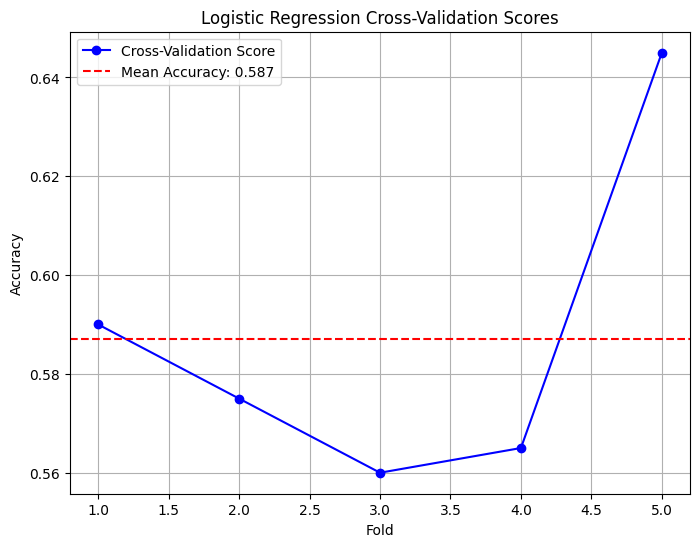

In [170]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)

# Perform Cross-Validation
scores_lr = cross_val_score(lr, X, y, cv=5)

# Print Cross-Validation Results
print(f"Logistic Regression Cross-Validation Scores: {scores_lr}")
print(f"Mean Accuracy: {scores_lr.mean()}")
print(f"Standard Deviation: {scores_lr.std()}")

# Plot the Cross-Validation Scores
plt.figure(figsize=(8,6))
plt.plot(range(1, 6), scores_lr, marker='o', linestyle='-', color='b', label='Cross-Validation Score')
plt.axhline(y=scores_lr.mean(), color='r', linestyle='--', label=f'Mean Accuracy: {scores_lr.mean():.3f}')
plt.title("Logistic Regression Cross-Validation Scores")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [145]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)  # Keep 95% of the variance
X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_)}")

# Train Logistic Regression model with PCA-transformed data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_pca, y)
scores_pca = cross_val_score(lr, X_pca, y, cv=5)
print(f"Cross-Validation Scores (PCA): {scores_pca}")
print(f"Mean Accuracy: {scores_pca.mean()}")



Explained Variance: [0.65563102 0.09335546 0.08975533 0.08290742 0.0155169  0.01270106
 0.01161819]
Total Variance Explained: 0.9614853728380774
Cross-Validation Scores (PCA): [0.635 0.585 0.61  0.64  0.645]
Mean Accuracy: 0.623


In [162]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Initialize Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10, min_samples_leaf=100, random_state=42)


# Perform Cross-Validation
scores_rf = cross_val_score(rf, X, y, cv=5)
print(f"Random Forest Cross-Validation Scores: {scores_rf}")
print(f"Mean Accuracy: {scores_rf.mean()}")
print(f"Standard Deviation: {scores_rf.std()}")


Random Forest Cross-Validation Scores: [0.865 0.885 0.865 0.825 0.905]
Mean Accuracy: 0.8690000000000001
Standard Deviation: 0.026532998322843223


Random Forest Cross-Validation Scores: [0.865 0.885 0.865 0.825 0.905]
Mean Accuracy: 0.8690000000000001
Standard Deviation: 0.026532998322843223


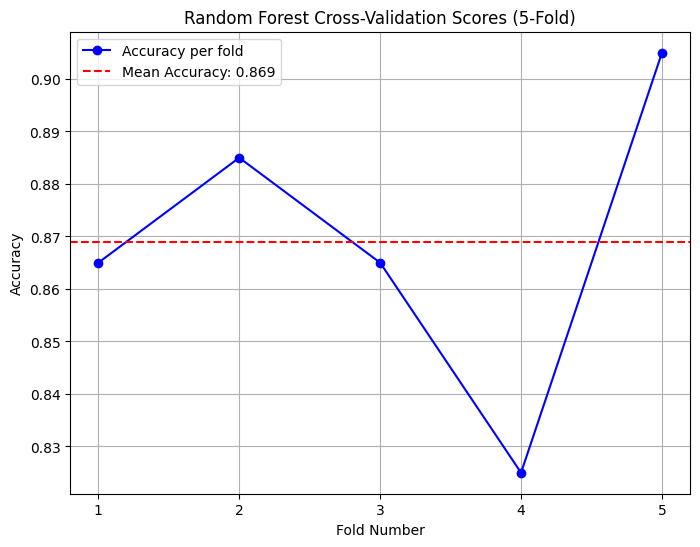

In [171]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Initialize Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10, min_samples_leaf=100, random_state=42)

# Perform Cross-Validation
scores_rf = cross_val_score(rf, X, y, cv=5)

# Print results
print(f"Random Forest Cross-Validation Scores: {scores_rf}")
print(f"Mean Accuracy: {scores_rf.mean()}")
print(f"Standard Deviation: {scores_rf.std()}")

# Plotting the cross-validation scores
plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), scores_rf, marker='o', linestyle='-', color='b', label='Accuracy per fold')
plt.axhline(y=scores_rf.mean(), color='r', linestyle='--', label=f'Mean Accuracy: {scores_rf.mean():.3f}')
plt.title("Random Forest Cross-Validation Scores (5-Fold)")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.legend(loc='best')
plt.grid(True)
plt.show()

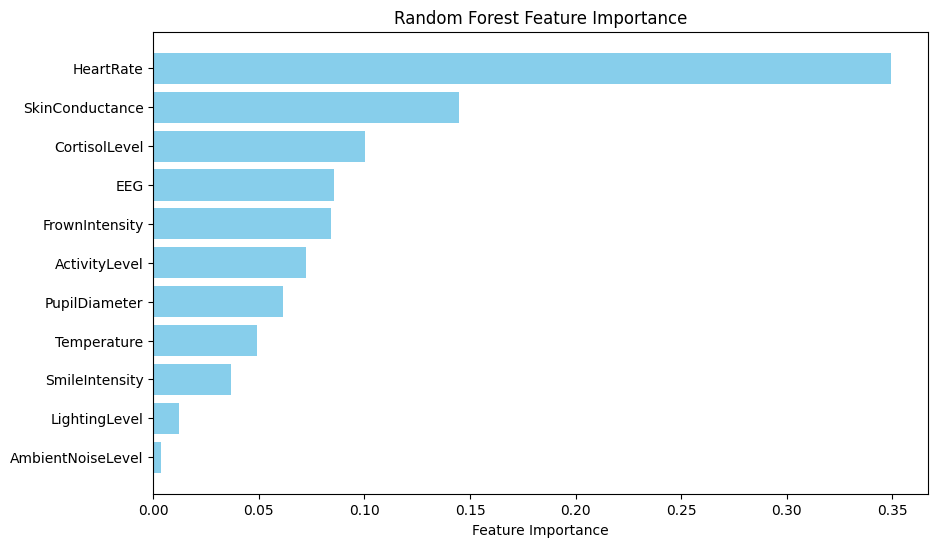

HeartRate: 0.3495
SkinConductance: 0.1450
CortisolLevel: 0.1001
EEG: 0.0856
FrownIntensity: 0.0841
ActivityLevel: 0.0722
PupilDiameter: 0.0615
Temperature: 0.0491
SmileIntensity: 0.0369
LightingLevel: 0.0121
AmbientNoiseLevel: 0.0038


In [164]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Assuming X and y are already defined (features and target variable)
# Initialize Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10, min_samples_leaf=100, random_state=42)

# Fit the model on the entire dataset (assuming X and y are available)
rf.fit(X, y)

# Get feature importances from the Random Forest model
feature_importances = rf.feature_importances_

# Create a bar plot of feature importances
features = X.columns  # Assuming X is a pandas DataFrame with feature names
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(features[indices], feature_importances[indices], align='center', color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.show()

# Display feature importances in console for reference
for i in range(X.shape[1]):
    print(f"{features[indices[i]]}: {feature_importances[indices[i]]:.4f}")



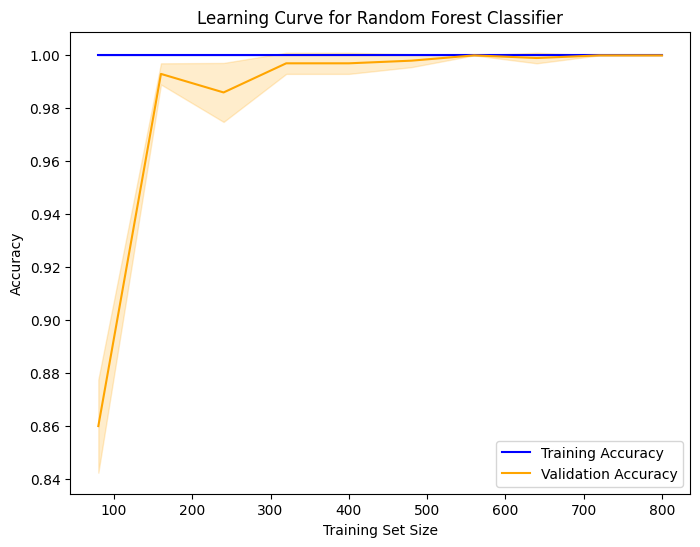

In [167]:
from sklearn.model_selection import learning_curve

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(rf, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Accuracy", color='blue')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Validation Accuracy", color='orange')
plt.fill_between(train_sizes, 
                 np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                 np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), 
                 color='blue', alpha=0.2)
plt.fill_between(train_sizes, 
                 np.mean(test_scores, axis=1) - np.std(test_scores, axis=1),
                 np.mean(test_scores, axis=1) + np.std(test_scores, axis=1), 
                 color='orange', alpha=0.2)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve for Random Forest Classifier")
plt.legend(loc="best")
plt.show()


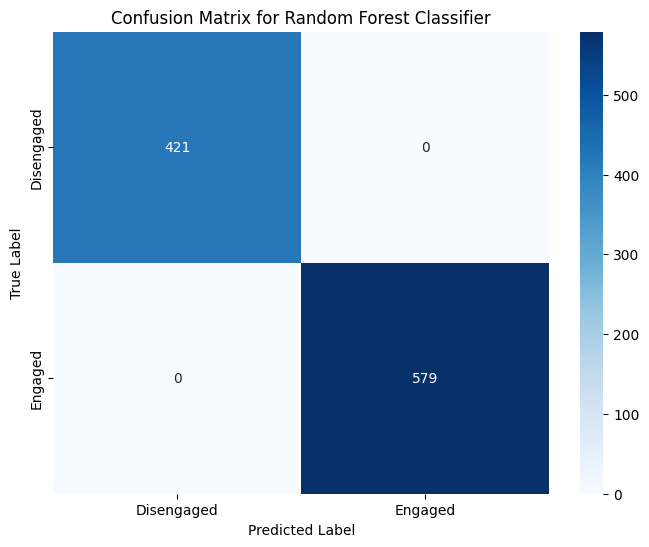

In [168]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Fit model and make predictions
rf.fit(X, y)
y_pred = rf.predict(X)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Disengaged', 'Engaged'], yticklabels=['Disengaged', 'Engaged'])
plt.title("Confusion Matrix for Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [169]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Assuming you have the true labels (y_test) and predicted labels (y_pred)
y_pred = rf.predict(X_test)  # For Random Forest model

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Precision, Recall, and F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# AUC (Assumes binary classification, for multi-class, you would use a one-vs-rest approach)
auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])  # Get the AUC for the positive class
print(f"AUC: {auc:.2f}")


Confusion Matrix:
[[ 91   0]
 [  0 109]]
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
AUC: 1.00
